In [50]:
# Import packages
import pandas as pd
import seaborn as sns   
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [37]:
# Load in data as df
df = pd.read_csv('data/apple_sales_data.csv')

In [38]:
# First look at the data
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [39]:
# Check the data types of the columns
df.dtypes

sale_id                    object
sale_date                  object
year                        int64
quarter                    object
month                      object
country                    object
region                     object
city                       object
product_name               object
category                   object
storage                    object
color                      object
unit_price_usd            float64
discount_pct                int64
units_sold                  int64
discounted_price_usd      float64
revenue_usd               float64
currency                   object
fx_rate_to_usd            float64
revenue_local_currency    float64
sales_channel              object
payment_method             object
customer_segment           object
customer_age_group         object
previous_device_os         object
customer_rating           float64
return_status              object
dtype: object

In [103]:
# Change sale date to datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])

df['month_calender'] = df['sale_date'].dt.to_period('M').dt.to_timestamp()

df['revenue_no_discount_usd'] = df['unit_price_usd'] * df['units_sold']

df_sub = df[['revenue_usd', 'revenue_no_discount_usd', 'discount_pct']]
df_sub.head()

,revenue_usd,revenue_no_discount_usd,discount_pct
0,148.12,159.27,7
1,127.45,149.95,15
2,1175.68,1175.68,0
3,3865.54,3865.54,0
4,2153.01,2266.32,5


In [41]:
# Check for missing values in data
df.isna().sum()         # columns with missing values are acceptable

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   4804
color                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        8056
customer_rating           3360
return_status                0
dtype: int64

In [56]:
# Check descriptive statistics of the data
round(df.describe(),2)

,sale_date,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,11500,11500.00,11500.00,11500.00,11500.00,11500.00,11500.00,11500.00,1.150000e+04,8140.00
mean,2023-06-30 22:03:32.869564928,2023.00,807.85,3.84,2.02,777.37,1568.32,1029.41,1.464369e+06,4.00
min,2022-01-01 00:00:00,2022.00,26.69,0.00,1.00,22.73,23.00,0.79,2.130000e+01,3.00
25%,2022-09-29 00:00:00,2022.00,180.15,0.00,1.00,178.30,305.74,0.92,1.041690e+03,3.50
50%,2023-06-27 00:00:00,2023.00,593.90,2.00,1.00,573.42,833.04,7.24,6.164160e+03,4.00
75%,2024-04-02 00:00:00,2024.00,958.39,7.00,3.00,928.57,1748.36,91.50,7.471653e+04,4.50
max,2024-12-31 00:00:00,2024.00,7551.01,15.00,8.00,7551.01,59529.52,24500.00,5.075175e+08,5.00
std,NaN,0.82,1112.44,4.78,1.44,1072.92,2839.76,4072.33,9.941160e+06,0.58


In [ ]:
# Check for duplicates in the data
df.duplicated().sum()    # no duplicates in the data

0

In [62]:
df.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [67]:
df.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

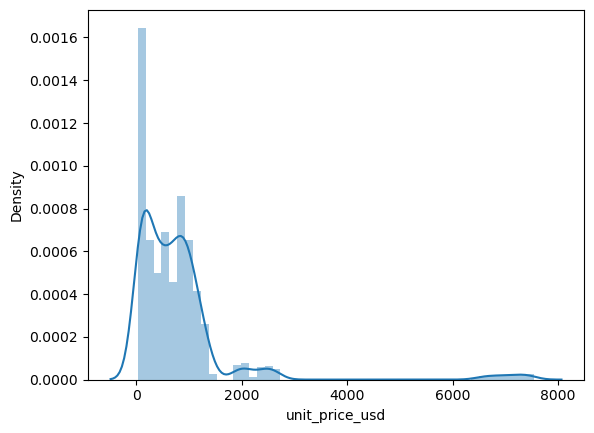

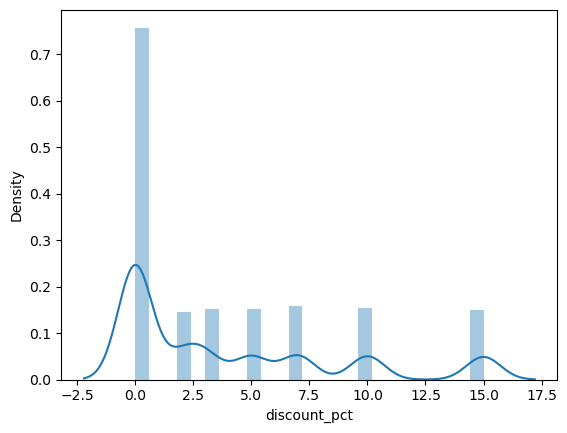

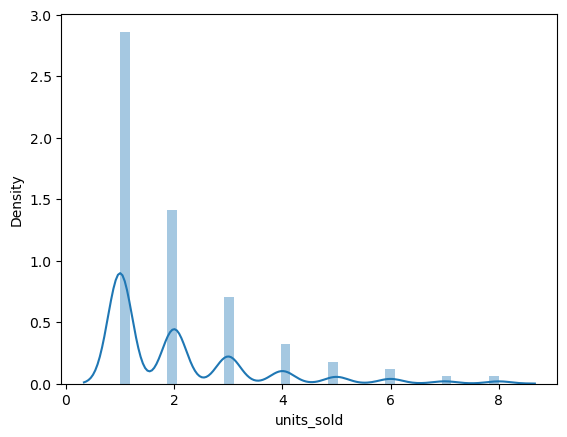

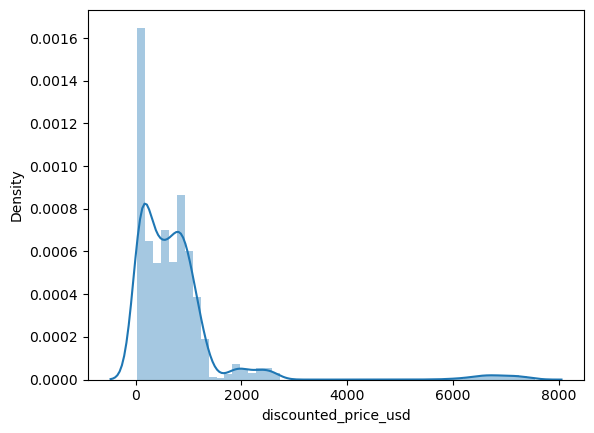

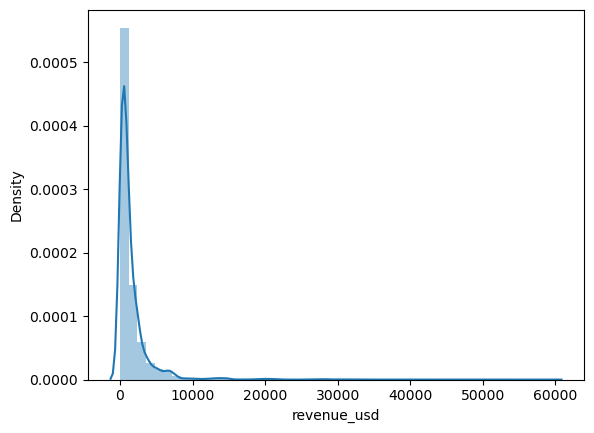

In [69]:
# Create plots of numerical columns to see distribution
columns = df[['unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
              'revenue_usd']]

for i in columns:
    sns.distplot(df[i])
    plt.show()


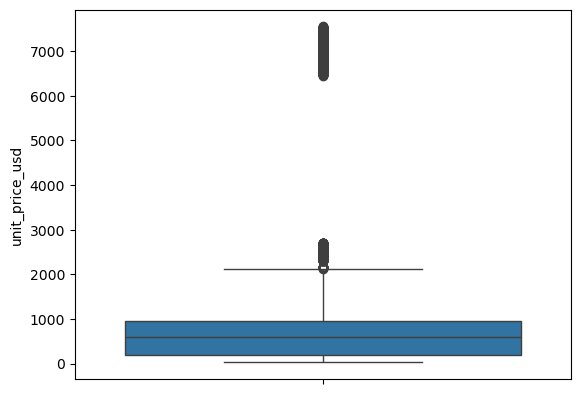

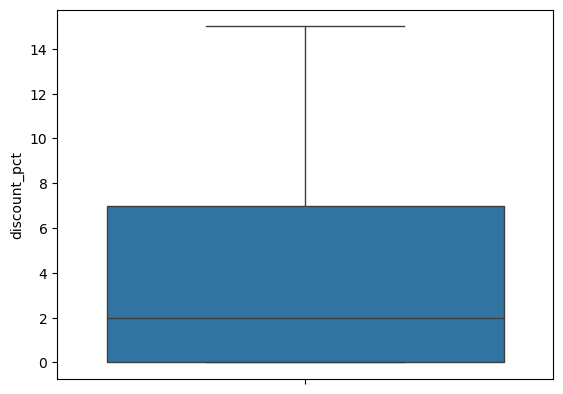

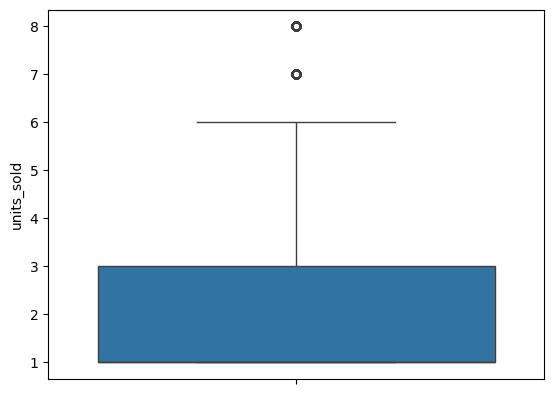

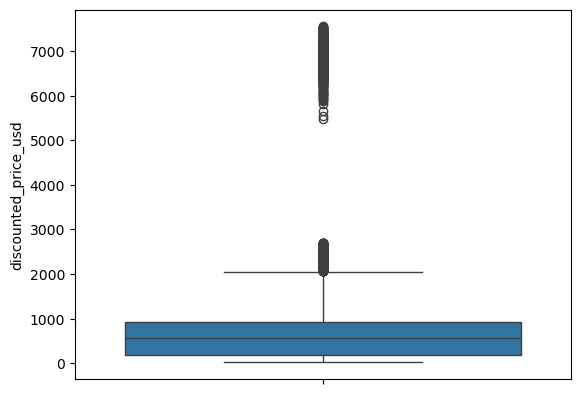

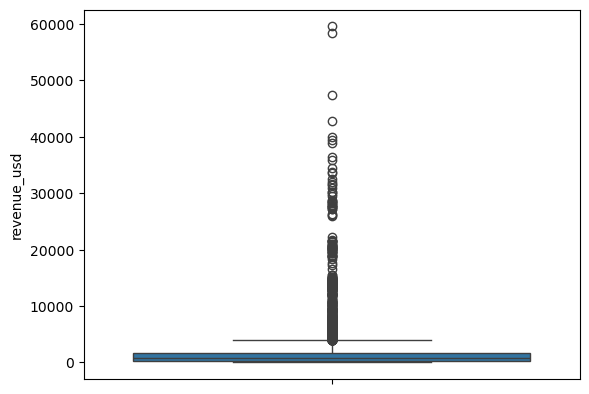

In [70]:
# Create graphs for numerical columns to see outliers
for i in columns:
    sns.boxplot(df[i])
    plt.show()

In [92]:
# Run value counts of categorical columns to see if there are any issues
columns_char = df.select_dtypes(include='object').columns


In [74]:
df['quarter'].value_counts()

quarter
Q4    2922
Q1    2894
Q3    2864
Q2    2820
Name: count, dtype: int64

In [75]:
df['month'].value_counts()

month
March        1047
October      1022
July          976
December      975
August        964
April         961
January       960
June          937
November      925
September     924
May           922
February      887
Name: count, dtype: int64

In [76]:
df['country'].value_counts()

country
Japan             274
Mexico            269
Thailand          267
Canada            265
Poland            262
Finland           262
Argentina         261
Australia         258
Taiwan            257
Malaysia          257
Hong Kong         254
Italy             254
France            254
Sweden            253
South Korea       252
Denmark           252
Netherlands       251
Germany           249
Philippines       248
New Zealand       248
Brazil            246
Kenya             246
Pakistan          244
Indonesia         244
Colombia          244
Saudi Arabia      243
Switzerland       243
Turkey            243
UAE               243
Portugal          242
Egypt             242
Spain             241
United Kingdom    239
Chile             239
Russia            237
Singapore         237
Bangladesh        234
Ireland           232
China             230
South Africa      230
Vietnam           229
United States     228
Austria           227
Nigeria           225
Belgium           221
No

In [80]:
df['region'].value_counts()

region
Europe           3898
Asia             3435
South America     990
Africa            943
North America     762
Oceania           506
Middle East       486
Europe/Asia       480
Name: count, dtype: int64

In [82]:
df['sales_channel'].value_counts()

sales_channel
Online (Apple.com)      1940
Authorized Reseller     1925
Carrier Store           1917
Apple Store             1914
Corporate / B2B         1912
Third-Party Retailer    1892
Name: count, dtype: int64

In [87]:
df['customer_segment'].value_counts()

customer_segment
Government    2892
Individual    2885
Education     2884
Business      2839
Name: count, dtype: int64

In [88]:
df['customer_age_group'].value_counts()

customer_age_group
25–34    2347
18–24    2343
45–54    2283
55+      2271
35–44    2256
Name: count, dtype: int64

In [90]:
df['previous_device_os'].value_counts() # non-relevant for the dashboard

previous_device_os
Android     595
iOS 16      587
Other       581
New User    571
iOS 15      556
iOS 17      554
Name: count, dtype: int64

In [93]:
df['return_status'].value_counts()

return_status
Kept         10143
Returned       898
Exchanged      459
Name: count, dtype: int64